In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [17]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [18]:
I_points = [10, 20, 30, 40, 50]

dyn_sim_log = {}
stat_sim_log = {}

for RHC in [0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [323.15,333.15,343.15]:
            states_dyn = []
            states_stat = []
            time_evolutions = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 90), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {}
                time_evo = {}
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                    time_evo[var_name] = model.elec_variables[var_name]

                states_dyn.append(states)
                time_evolutions.append(time_evo)
                # --------------- Steady-state Simulation  --------------- #
                operating_inputs_stat = operating_inputs.copy()
                operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                        'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                        'Win_c': 4.8, 'Wout_c': 22.7, 'Win_a': 4.8, 'Wout_a': 4.8}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)

            # --------------- Log states for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn]
            dyn_sim_log["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions}
            stat_sim_log["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

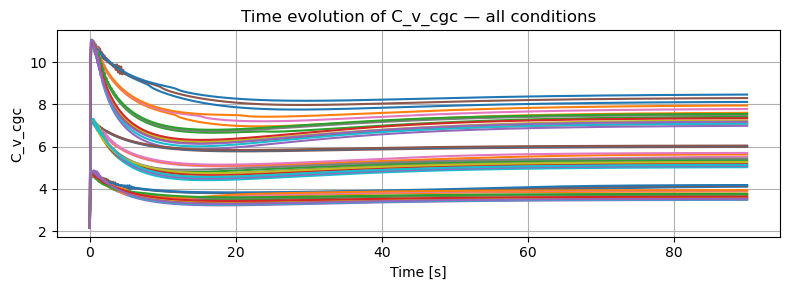

In [27]:

fig, ax = plt.subplots(figsize=(8, 3))

for cond_key, cond_data in dyn_sim_log.items():
    for j, I in enumerate(I_points):
        te = cond_data["time_evolution"][j]
        ax.plot(te["t"], te["C_v_cgc"], label=f"{cond_key}, I={I}A")

ax.set_xlabel("Time [s]")
ax.set_ylabel("C_v_cgc")
ax.set_title("Time evolution of C_v_cgc — all conditions")
ax.grid(True)
fig.tight_layout()
plt.show()


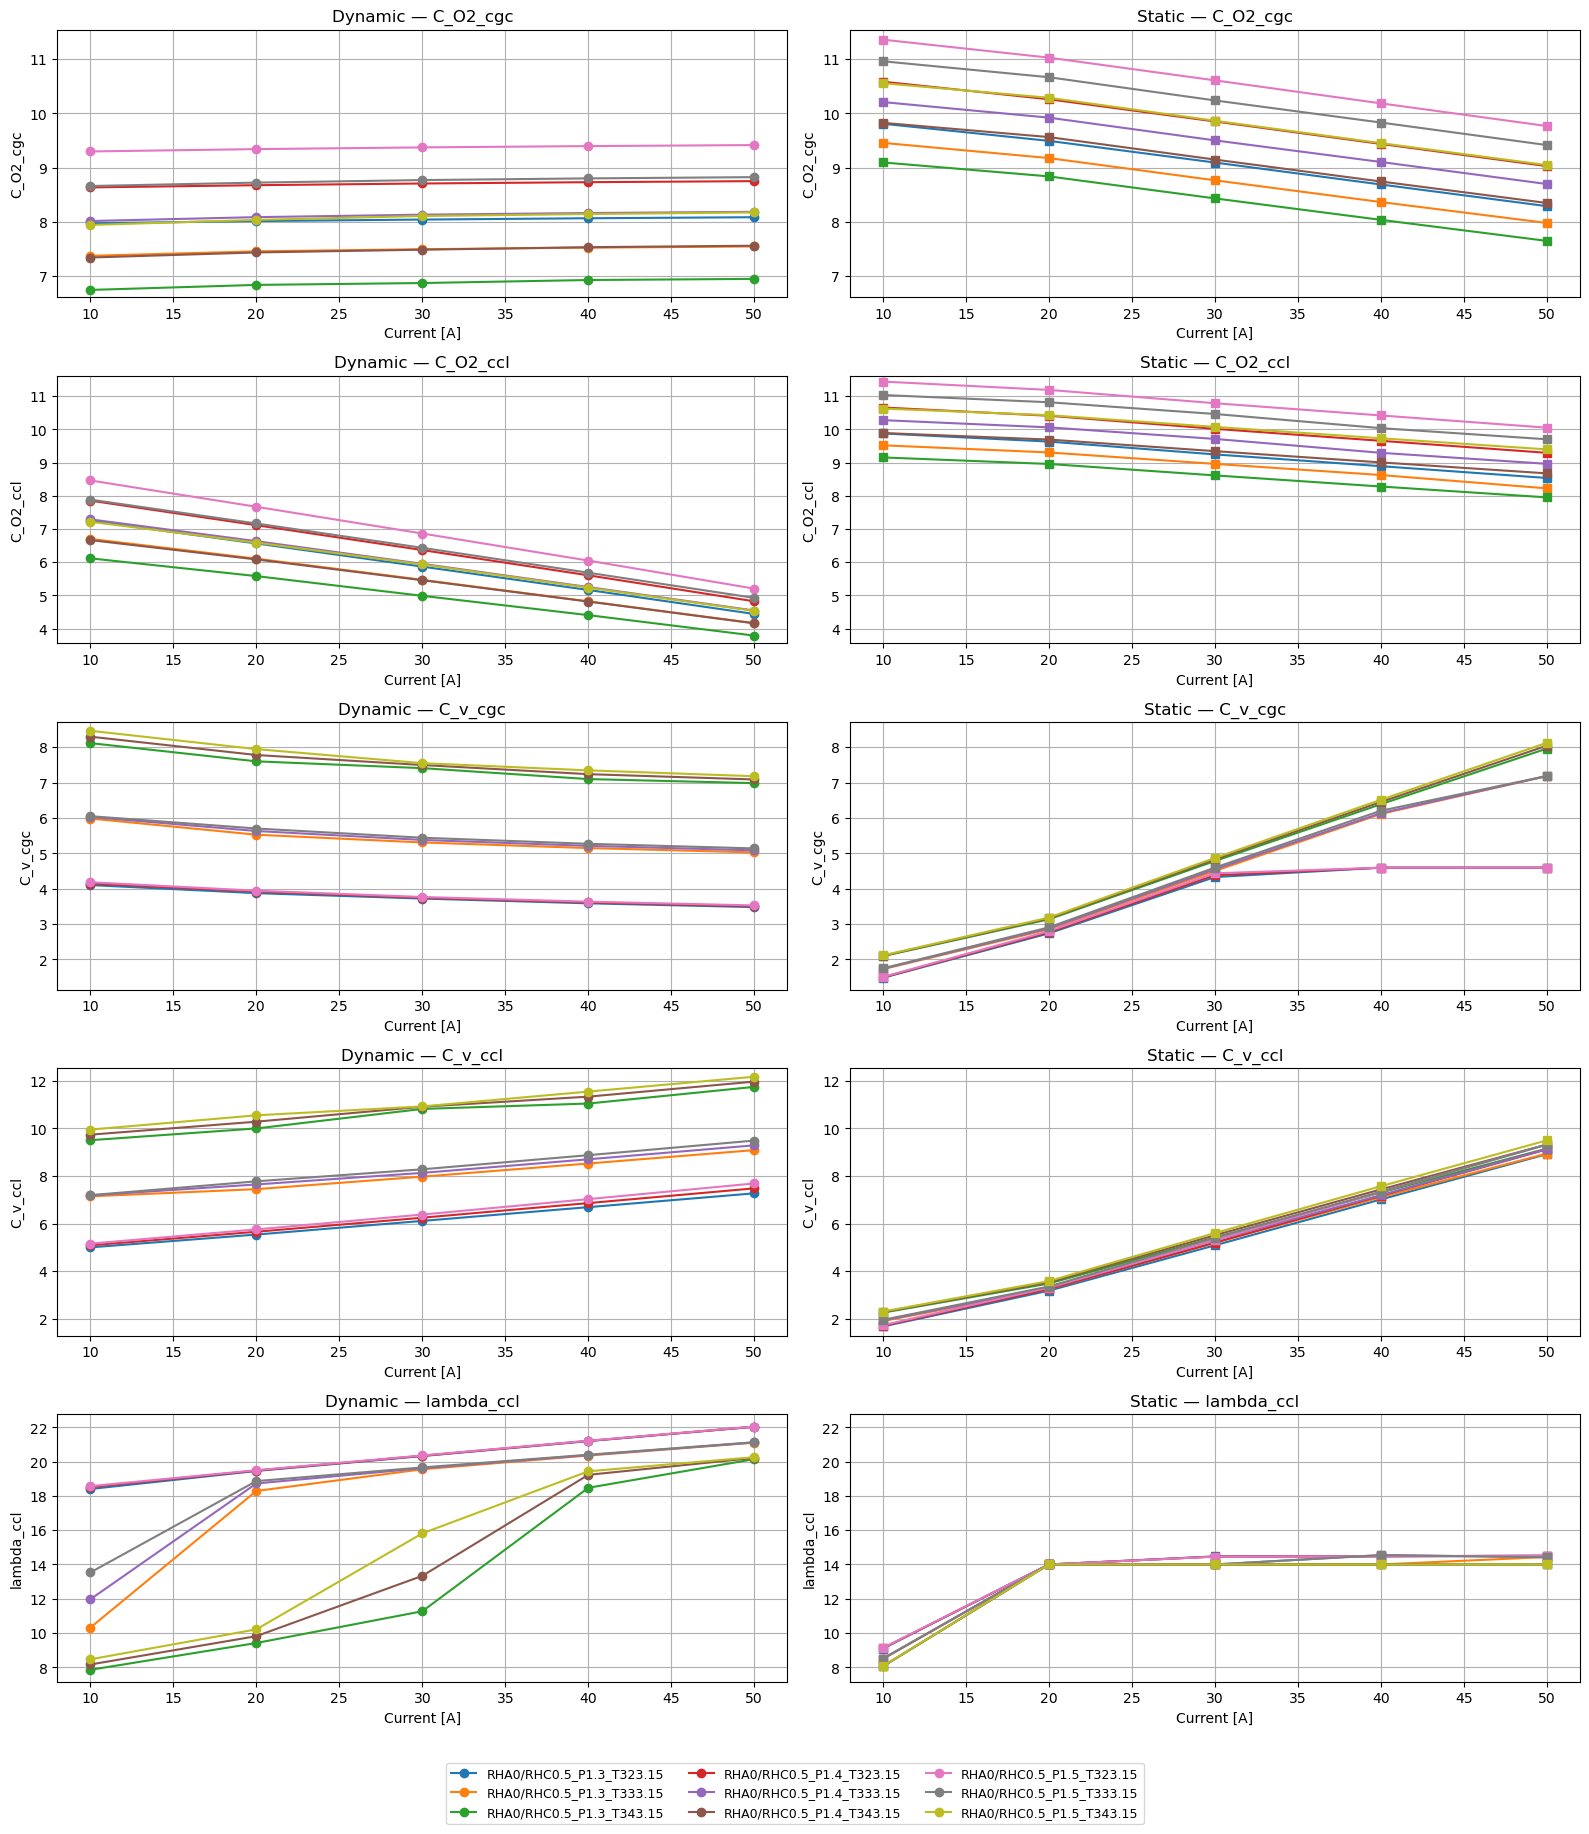

In [30]:
dyn_vars = ["C_O2_cgc", "C_O2_ccl", "C_v_cgc", "C_v_ccl", "lambda_ccl"]
stat_var_map = {"C_O2_cgc": "C_O2_cgc", "C_O2_ccl": "C_O2_ccl",
                           "C_v_cgc": "Cv_cgdl", "C_v_ccl": "Cv_ccl", "lambda_ccl": "lambda_ccl"}

fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(16, 18))

for row, var in enumerate(dyn_vars):
    # --- Dynamic (left column) ---
    ax_dyn = axs[row, 0]
    for cond_key in dyn_sim_log:
        vals = dyn_sim_log[cond_key]["states"][var]
        ax_dyn.plot(I_points, vals, marker='o', label=cond_key)
    ax_dyn.set_xlabel("Current [A]")
    ax_dyn.set_ylabel(var)
    ax_dyn.set_title(f"Dynamic — {var}")
    ax_dyn.grid(True)

    # --- Static (right column) ---
    ax_stat = axs[row, 1]
    stat_key = stat_var_map[var]
    for cond_key in stat_sim_log:
        states_list = stat_sim_log[cond_key]["states"]
        if stat_key == "Cv_cgdl":
            vals = [s[stat_key][-1] for s in states_list]  # GC-side boundary
        else:
            vals = [s[stat_key] for s in states_list]
        ax_stat.plot(I_points, vals, marker='s', label=cond_key)
    ax_stat.set_xlabel("Current [A]")
    ax_stat.set_ylabel(var)
    ax_stat.set_title(f"Static — {var}")
    ax_stat.grid(True)

    # --- Sync y-axis limits for the row ---
    ymin = min(ax_dyn.get_ylim()[0], ax_stat.get_ylim()[0])
    ymax = max(ax_dyn.get_ylim()[1], ax_stat.get_ylim()[1])
    ax_dyn.set_ylim(ymin, ymax)
    ax_stat.set_ylim(ymin, ymax)

# Single legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()
